# Risk profile and strategy evaluation on an example equity portfolio

**Summary**:
An 8-stock technology portfolio was analysed over Sept 2021 - Sept 2026 using daily IBKR adjusted close data. Held at current weights, it returned 54% yearly with 43% annual volatility, and a max drawdown of -58%. This is compared to the SPX benchmark which achieved 12%, 17%, and 25% respectively. The portfolio's market beta is ~1.9, with a strong large-cap growth tilt. An annual alpha of ~30-35% was observed, though likely inflated by today's weights. A walk-forward SMA-crossover strategy was backtested using a 5/21 short/long window split, returning 5.5% yearly with a Sharpe of 0.08, at 10 bps costs. In comparison, a long-only strategy achieved 55% yearly returns with a Sharpe of 1.49 at similar costs. The best of 14 window pairs (10/200) has a Deflated Sharpe Ratio of 0.35, so this performance cannot be distinguished from luck.

**Contents**:
1. Setup
2. Data
3. Portfolio risk profile
4. Strategy backtest
5. Limitations
6. Conclusions
7. References

## 1. Setup

Using commit: 2a4f5d5bed6b9a1ad7e3a34c471e514963482be2 </br>
Python version: 3.14 </br>
Using DevConfig from [config](https://github.com/Sarkar-shreyas/portfolio/blob/master/src/backend/config.py "Config file") </br>
See [readme](https://github.com/Sarkar-shreyas/portfolio/blob/master/README.md "README file") for installation instructions

In [1]:
# If necessary, use this to resolve the path.
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
# Main and lazy imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.backend.config import DevConfig
from src.backend.analysis import *
from src.backend.portfolio_construction import *
from src.backend.strategy import *
from src.backend.simulations import *
from src.backend.backtest import *
from src.backend.vis import *
from src.backend.data import *

In [3]:
# Initialising the IBKR App and config classes
app = IBApp()
config = DevConfig()

## 2. Data

**Sources**: 
Ticker data is fetched using IBKR and stored in a cache folder (src/backend/cache). </br>
Market capitalization for each ticker can be obtained using get_market_cap(), then added to the portfolio dataframe and saved in the cache as well. </br>
Fama french factors are stored in the cache after the csv file in the project root is cleaned, but may alternatively be obtained with pandas_datareader. </br>
The ticker universe for this case study is ['AAPL', 'AMD', 'AVGO', 'NVDA', 'ORCL', 'PLTR', 'QCOM', 'TSM']. </br>
SPX data is used as the benchmark.

In [4]:
spx_data = get_benchmark_data(app, config, 1)
port_df = get_portfolio_data(app, config)
ticker_universe = ['AAPL', 'AMD', 'AVGO', 'NVDA', 'ORCL', 'PLTR', 'QCOM', 'TSM']

# IBKR has specific contract IDs for each ticker - this will be the index for portfolio.csv if get_portfolio_data() is called beforehand
# The IDs can then be obtained by loading the existing csv file, or accessing port_df[ticker]['id']
contract_ids = {ticker: port_df[ticker]['id'] for ticker in ticker_universe}

# Store the ticker data in a dictionary with tickers as keys
equity_data = {}
i = 3 # request ID number.
for ticker in ticker_universe:
    data = get_equity_data(app, config, contract_ids[ticker], ticker, "5 Y", i)
    data['datetime'] = pd.to_datetime(data['datetime'], format="%Y-%m-%d")
    cleaned_df = data.set_index('datetime')
    cleaned_df['return'] = simple_returns(cleaned_df['close']) # Add the simple returns to the dataframe immediately
    equity_data[ticker] = cleaned_df
    i += 1

Loading existing portfolio data
Loading existing AAPL data.
Loading existing AMD data.
Loading existing AVGO data.
Loading existing NVDA data.
Loading existing ORCL data.
Loading existing PLTR data.
Loading existing QCOM data.
Loading existing TSM data.


<class 'pandas.DataFrame'>
DatetimeIndex: 1253 entries, 2021-09-27 to 2026-09-23
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    1253 non-null   float64
 1   close   1253 non-null   float64
 2   high    1253 non-null   float64
 3   low     1253 non-null   float64
 4   volume  1253 non-null   int64  
 5   return  1252 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 68.5 KB
None


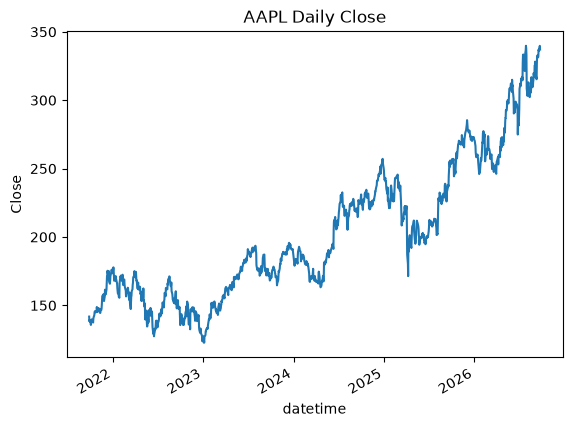

In [5]:
print(equity_data['AAPL'].info()) # Quick inspection to check index type matches and returns column is present
equity_data['AAPL']['close'].plot(ylabel='Close', title='AAPL Daily Close') # Quick plot to observe behaviour
plt.show()

In [6]:
# Turn the ticker data into close price, returns and volume panels
close_panel = to_panel(equity_data, 'close')
volume_panel = to_panel(equity_data, 'volume')
return_panel = to_panel(equity_data, 'return')
close_panel.info() # Quick inspection to verify the ticker universe and DateTimeIndex survived

<class 'pandas.DataFrame'>
DatetimeIndex: 1253 entries, 2021-09-27 to 2026-09-23
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1253 non-null   float64
 1   AMD     1253 non-null   float64
 2   AVGO    1253 non-null   float64
 3   NVDA    1253 non-null   float64
 4   ORCL    1253 non-null   float64
 5   PLTR    1253 non-null   float64
 6   QCOM    1253 non-null   float64
 7   TSM     1253 non-null   float64
dtypes: float64(8)
memory usage: 88.1 KB


In [7]:
# The benchmark comes back with a 'datetime' column, so index it the same way as the equities
spx = spx_data.assign(datetime=pd.to_datetime(spx_data['datetime'], format="%Y-%m-%d")).set_index('datetime')

# Alignment checks: every ticker and the benchmark should share one date index with no gaps
print(f"Period: {close_panel.index[0].date()} to {close_panel.index[-1].date()}, {len(close_panel)} daily bars")
print(f"Equity dates missing from SPX: {len(close_panel.index.difference(spx.index))}")
print(pd.DataFrame({
    'missing closes': close_panel.isna().sum(),
    'non-positive volume bars': (volume_panel <= 0).sum(),
    'largest abs daily return': return_panel.abs().max(),
}))

Period: 2021-09-27 to 2026-09-23, 1253 daily bars
Equity dates missing from SPX: 0
      missing closes  non-positive volume bars  largest abs daily return
AAPL               0                         0                  0.153236
AMD                0                         0                  0.238205
AVGO               0                         0                  0.244341
NVDA               0                         0                  0.243758
ORCL               0                         0                  0.359479
PLTR               0                         0                  0.308014
QCOM               0                         0                  0.151864
TSM                0                         0                  0.133284


In [8]:
# The first row has no prior close, so it carries no return
return_panel = return_panel.iloc[1:]
spx_returns = simple_returns(spx['close']).rename('SPX').reindex(return_panel.index)

# Fama-French five factors, published in percent with YYYYMMDD dates
ff = get_fama_factors(config)
ff.index = pd.to_datetime(ff.index.astype(str))
ff = ff.loc[return_panel.index[0]:return_panel.index[-1]] / 100
print(f"Factor data covers {ff.index[0].date()} to {ff.index[-1].date()} ({len(ff)} days)")

Loading cached Fama-French data.
Factor data covers 2021-09-28 to 2026-07-31 (1215 days)


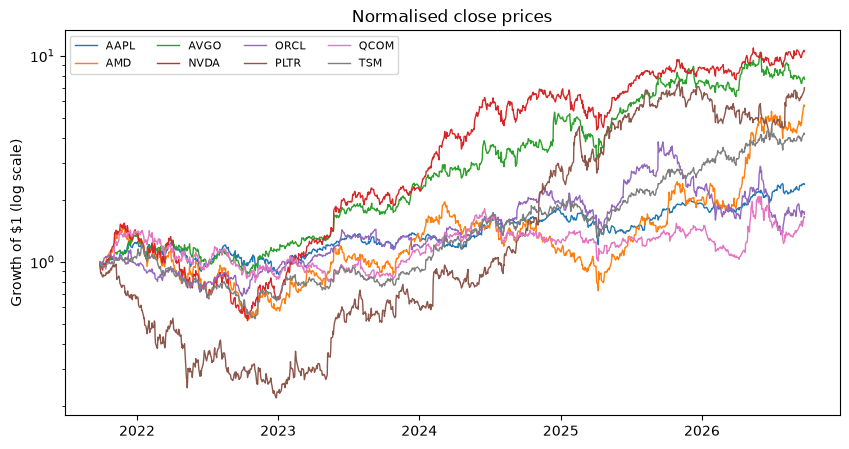

In [9]:
# Sanity plot: prices rebased to 1 on the first date, log scale so splits or bad ticks stand out as jumps
normalised = close_panel / close_panel.iloc[0]
fig, ax = plt.subplots(figsize=(10, 5))
plot_timeseries(normalised, ax, {'label': list(normalised.columns), 'linewidth': 1})
ax.set_yscale('log')
ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('Normalised close prices')
ax.legend(ncol=4, fontsize=8)
plt.show()

**Sanity check**: There were no missing closes, 0 date mismatches with SPX, 0 bars with zero or negative volume. NVDA and AVGO had 10:1 splits in June & July 2024, but neither exhibit a significant jump at those times. This indicates the adjusted close prices pulled from IBKR are reasonable. The large selloff throughout 2022 coincided with the Federal Reserve tightening rates, and the huge bear market persisted over the year. The next large drop occurring in April 2025 coincided with the tariffs imposed by the US. Nothing else particularly stands out.

## 3. Portfolio risk profile

Using methods from the analysis module, observe how risky the portfolio is, and where that risk comes from.

**Portfolio construction.** The portfolio weights are the current market values of the eight holdings, normalised to sum to one. They are held constant and rebalanced daily, so the portfolio return on each date is the weighted sum of that day's asset returns. The weights are used in the calculations but not printed, so position sizes stay private.

Two reference weightings of the same universe are shown alongside it, an equal-weight portfolio and a market-cap-weighted one, together with the S&P 500 (SPX).

In [10]:
holdings_value = pd.Series({ticker: port_df[ticker]['marketValue'] for ticker in ticker_universe})
holdings_weights = holdings_value / holdings_value.sum()

eq_weights = equal_weight_benchmark(config, ticker_universe)
cap_weights = mkt_cap_weight_benchmark(config, pd.Series({ticker: port_df[ticker]['MktCap'] for ticker in ticker_universe}))

portfolios = pd.DataFrame({
    'Holdings': return_panel.mul(holdings_weights, axis=1).sum(axis=1),
    'Equal weight': return_panel.mul(eq_weights, axis=1).sum(axis=1),
    'Cap weight': return_panel.mul(cap_weights, axis=1).sum(axis=1),
    'SPX': spx_returns,
})
port_returns = portfolios['Holdings']

In [11]:
def perf_summary(returns: pd.DataFrame) -> pd.DataFrame:
    """Headline performance and risk statistics for each column of a daily returns frame."""
    stats = {
        'Cumulative return': lambda x: cumulative_returns(x).iloc[-1],
        'Ann. return': lambda x: ann_returns(config, x),
        'Ann. volatility': lambda x: ann_volatility(config, x),
        'Sharpe': lambda x: ann_sharpe(config, x),
        'Sortino': lambda x: ann_sortino(config, x),
        'Max drawdown': lambda x: max_drawdown(config, x),
        'Calmar': lambda x: ann_calmar(config, x),
    }
    return pd.DataFrame({name: returns.apply(fn) for name, fn in stats.items()})


def fmt(df: pd.DataFrame, pct='all', decimals: int = 1) -> pd.DataFrame:
    """Display copy of a table: `pct` columns as percentages, everything else rounded to 2 dp."""
    out = df.round(2).astype(object)
    for col in (df.columns if pct == 'all' else pct):
        out[col] = df[col].map(lambda v: f'{v:.{decimals}%}' if pd.notna(v) else '-')
    return out

### 3.1 Returns

In [12]:
perf = perf_summary(portfolios)
fmt(perf[['Cumulative return', 'Ann. return']])

,Cumulative return,Ann. return
Holdings,765.5%,54.4%
Equal weight,446.5%,40.8%
Cap weight,513.6%,44.1%
SPX,73.4%,11.7%


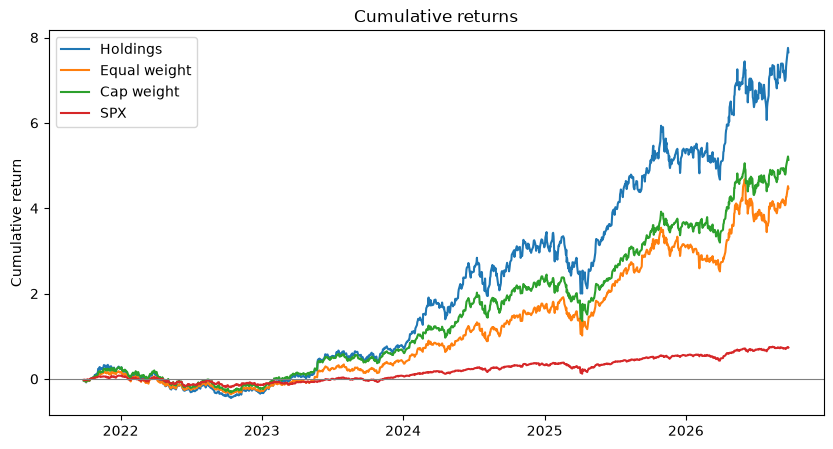

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
cum = portfolios.apply(cumulative_returns)
plot_timeseries(cum, ax, {'label': list(cum.columns)})
ax.axhline(0, color='grey', linewidth=0.8)
ax.set_ylabel('Cumulative return')
ax.set_title('Cumulative returns')
ax.legend()
plt.show()

,max,min,mean,median,std,skew,kurtosis,0.25,0.75,iqr
Holdings,0.179634,-0.135566,0.002083,0.002546,0.026827,0.337219,3.758319,-0.013238,0.017682,0.030920
Equal weight,0.169008,-0.087133,0.001589,0.002378,0.021580,0.244896,3.676445,-0.010916,0.013680,0.024596
Cap weight,0.168902,-0.092103,0.001678,0.002086,0.021437,0.363241,4.533696,-0.010590,0.013398,0.023988
SPX,0.095154,-0.059750,0.000497,0.000693,0.010738,0.163014,6.935045,-0.004811,0.006273,0.011084


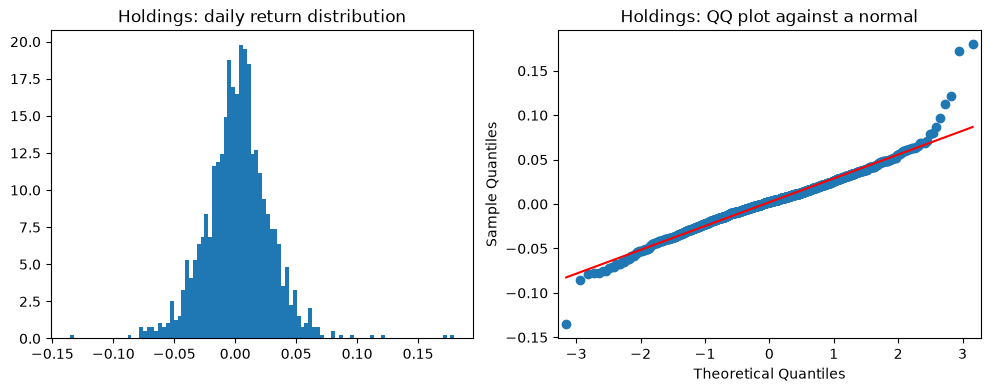

In [14]:
# Distribution of daily portfolio returns: moments and quantiles, then histogram and QQ plot against a normal
display(get_metrics(portfolios))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_hist(port_returns, axes[0], {'bins': 100, 'density': True})
axes[0].set_title('Holdings: daily return distribution')
plot_qq(port_returns, axes[1], {'line': 's'})
axes[1].set_title('Holdings: QQ plot against a normal')
plt.show()

The kurtosis of every portfolio above is much greater than 0, ranging from 3.68 to 6.93. Pandas returns kurtosis in excess of the standard normal, so we would observe a value of 0 if the data was normally distributed. This indicates significantly fat tails, while the positive skew indicates a rightward skewness of the distribution. Although a positive skew is a little uncommon in equities, it does match a momentum-driven period. </br>
The holdings displays a significantly larger cumulative returns than the equally-weighted and market-cap-weighted portfolios (765% vs 446% and 513%), indicating the weights of the holdings play a significant role in its performance. Comparatively, the SPX cumulative returns of 73% appears much worse. It is important to note - the weights are today's market values - NVDA is about half this book *because* it went up so much over this timeframe. </br>
The standard deviation of the portfolios are at least double that of the SPX standard deviation, or greater. This suggests that the portfolios constructed from the selected ticker universe have much higher risk than the benchmark SPX, with the potential for far greater returns.

### 3.2 Volatility

In [15]:
fmt(perf[['Ann. volatility', 'Sharpe', 'Sortino']], pct=['Ann. volatility'])

,Ann. volatility,Sharpe,Sortino
Holdings,42.6%,1.19,2.11
Equal weight,34.3%,1.08,1.89
Cap weight,34.0%,1.19,2.09
SPX,17.0%,0.47,0.78


mu          0.262751
omega       0.366423
alpha[1]    0.062962
beta[1]     0.887591
Name: params, dtype: float64


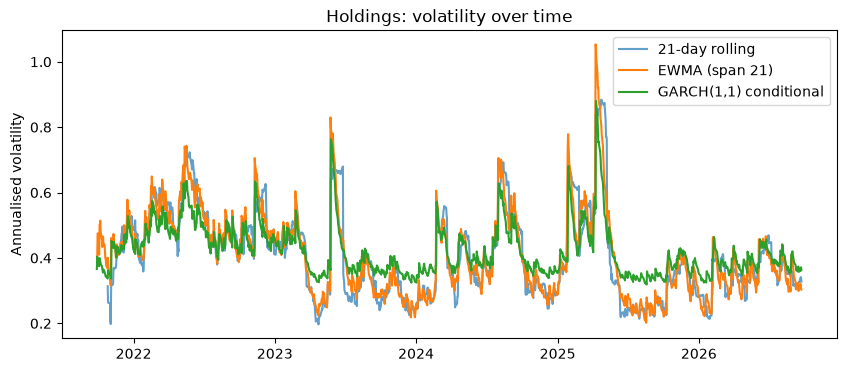

In [16]:
# Three volatility estimates for the holdings portfolio, all annualised
ann_factor = np.sqrt(config.annualise)
garch = fit_garch(
    config,
    port_returns * 100,  # arch fits more reliably on percentage returns
    {'vol': config.garch_vol, 'p': config.garch_p, 'o': config.garch_o, 'q': config.garch_q, 'dist': config.garch_dist},
    {'disp': 'off'},
)
print(garch.params)

fig, ax = plt.subplots(figsize=(10, 4))
plot_timeseries(rolling_volatility(config, port_returns, config.vol_window) * ann_factor, ax, {'label': f'{config.vol_window}-day rolling', 'alpha': 0.7})
plot_timeseries(ewma_volatility(config, port_returns) * ann_factor, ax, {'label': f'EWMA (span {config.ema_window})'})
plot_timeseries(garch.conditional_volatility / 100 * ann_factor, ax, {'label': 'GARCH(1,1) conditional'})
ax.set_ylabel('Annualised volatility')
ax.set_title('Holdings: volatility over time')
ax.legend()
plt.show()

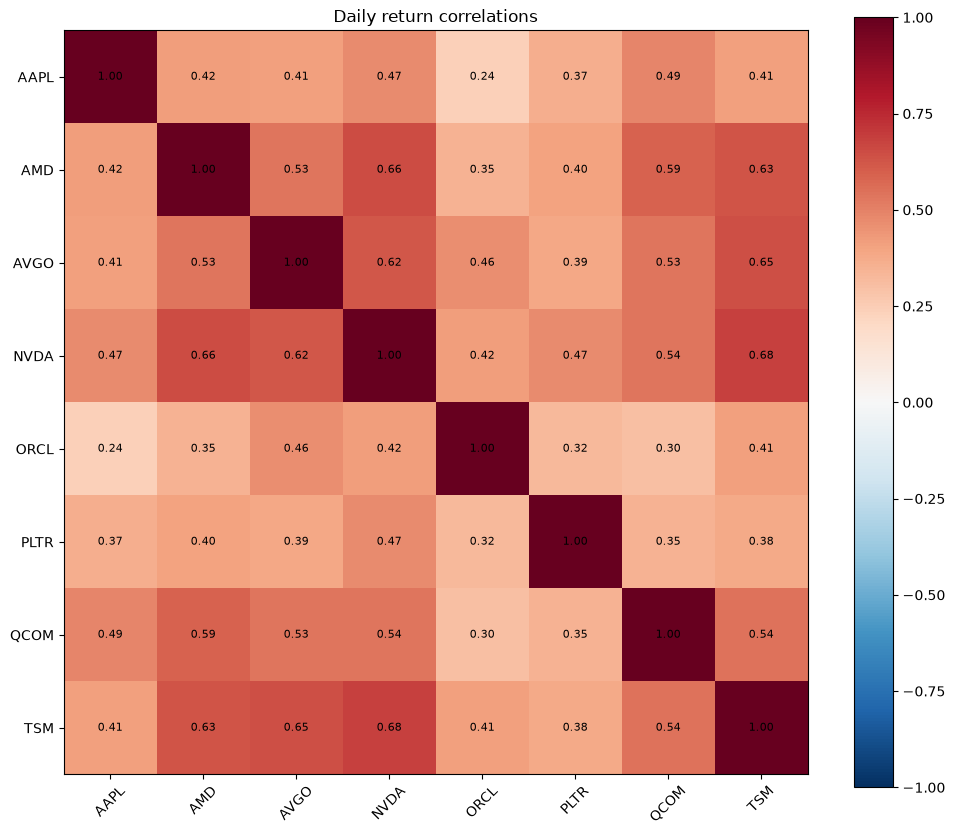

In [17]:
# Correlation between constituents: how much diversification the holdings actually provide
corr = get_correlation(return_panel)
fig, ax = plt.subplots(figsize=(12, 10))
im = heatmap(corr, ax, {'cmap': 'RdBu_r', 'vmin': -1, 'vmax': 1})
ax.set_xticks(range(len(corr)), corr.columns, rotation=45)
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Daily return correlations')
plt.show()

The GARCH fitting returns a $\alpha + \beta \approx 0.9505 \geq 0.95$, so there appears to be shocks persistent decaying with a half-life of ~14 days. There are no negative correlations present. This isn't too surprising as this portfolio is fully in the technology sector, and sector performance is likely a large factor contributing to their performance. This can be observed especially in the correlations between AMD, AVGO, NVDA and TSM all being $\gt 0.6$ - they are all huge semiconductor stocks and some of the main AI Boom winners. </br>
The annualised volatility of the equally-weighted portfolio remains far larger than the SPX benchmark (34% vs 17%), indicating diversification away from this sector may help reduce volatility. The Holdings and market-cap-weighted portfolio have identical Sharpe (1.19) and close to identical Sortino ratios (2.09 and 2,11), while the equally-weighted portfolio has a Sharpe and Sortino of 1.08 and 1.89 respectively. This is far greater than the 0.47 Sharpe and 0.78 Sortino ratios observed in SPX. The risk-adjusted performance of these portfolios are thus much better than the SPX benchmark's.

### 3.3 Drawdowns

,Max drawdown,Trough date,Calmar
Holdings,-58.2%,2022-10-14,0.87
Equal weight,-45.3%,2022-10-14,0.82
Cap weight,-46.4%,2022-10-14,0.87
SPX,-25.4%,2022-10-12,0.32


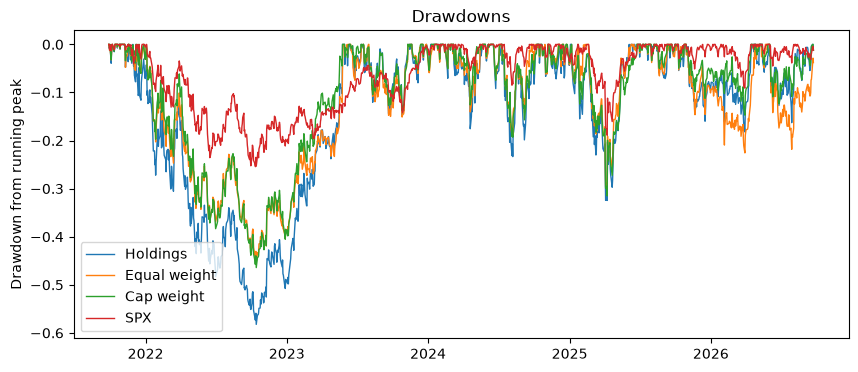

In [18]:
drawdowns = portfolios.apply(lambda x: daily_drawdowns(config, x))
dd_table = pd.DataFrame({
    'Max drawdown': perf['Max drawdown'],
    'Trough date': drawdowns.idxmin().dt.date,
    'Calmar': perf['Calmar'],
})
display(fmt(dd_table, pct=['Max drawdown']))

fig, ax = plt.subplots(figsize=(10, 4))
plot_timeseries(drawdowns, ax, {'label': list(drawdowns.columns), 'linewidth': 1})
ax.set_ylabel('Drawdown from running peak')
ax.set_title('Drawdowns')
ax.legend(loc='lower left')
plt.show()

The drawdowns for all three portfolios are far larger than the benchmark's drawdown. The max drawdown for the three portfolios shows that every portfolio fell at least ~45% at one point. The Calmar ratios of the three portfolios are far greater than that of SPX's (~0.8 vs 0.32), so the extra drawdown is somewhat compensated over the studied timeframe. All three portfolios hit their lowest on the same date (14th Oct 2022), likely due to the same cause - this was only 2 days after the lowest point for SPX. The time taken to recover from this trough in 2022 appears to be roughly ~8 months, where the drawdowns for the three portfolios were close to 0% in the middle of 2023.

### 3.4 Tail risk: VaR and CVaR

In [35]:
# One-day VaR and CVaR as returns (negative = loss). Historical uses the empirical distribution;
# Monte Carlo assumes jointly normal asset returns with the sample means and covariance.
mus = return_panel.mean()
Sigma = get_covariance(return_panel)
# Sigma = cov_shrinkage(config, return_panel)
tail_rows = {}
for conf in [0.95, 0.99]:
    mc_var, mc_cvar = mc_norm_port_var(config, mus, Sigma, holdings_weights, conf=conf)
    tail_rows[f'{conf:.0%}'] = {
        'Historical VaR': est_var(config, port_returns, conf),
        'Historical CVaR': cond_var(config, port_returns, conf),
        'MC normal VaR': mc_var,
        'MC normal CVaR': mc_cvar,
    }
fmt(pd.DataFrame(tail_rows).T, decimals=2)

,Historical VaR,Historical CVaR,MC normal VaR,MC normal CVaR
95%,-4.04%,-5.55%,-4.20%,-5.30%
99%,-6.61%,-7.86%,-6.01%,-6.90%


In [36]:
# Historical VaR and CVaR for every portfolio at the config confidence level
fmt(pd.DataFrame({
    'VaR': portfolios.apply(lambda x: est_var(config, x)),
    'CVaR': portfolios.apply(lambda x: cond_var(config, x)),
}), decimals=2)

,VaR,CVaR
Holdings,-4.04%,-5.55%
Equal weight,-3.31%,-4.56%
Cap weight,-3.16%,-4.54%
SPX,-1.64%,-2.46%


Expected breach rate at 95%: 5.0%
Normal               3.8%
Student-t (5 dof)    5.0%


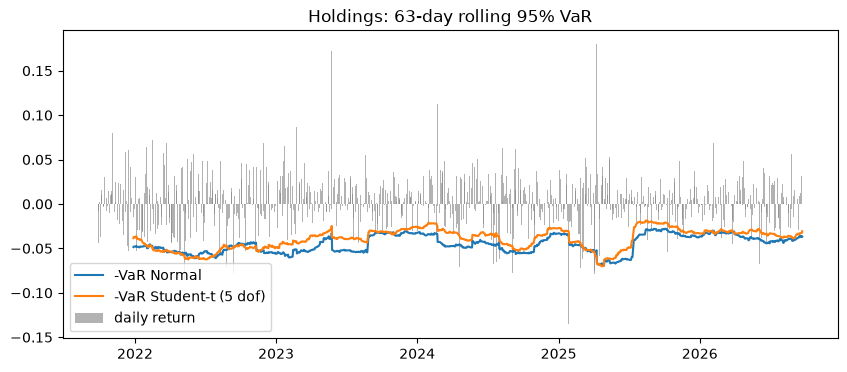

In [37]:
# Rolling parametric VaR, checked against realised returns. A breach is a day whose return falls
# below the previous day's VaR estimate, so the estimate only uses data available beforehand.
var_window = config.beta_window
rolling_var = pd.DataFrame({
    'Normal': norm_parametric_var(config, port_returns, window=var_window),
    'Student-t (5 dof)': t_parametric_var(config, port_returns, window=var_window),
}).shift(1)

breaches = rolling_var.apply(lambda v: (port_returns < -v)[v.notna()])
print(f"Expected breach rate at {config.var_conf:.0%}: {1 - config.var_conf:.1%}")
print(breaches.mean().map('{:.1%}'.format).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(port_returns.index, port_returns, width=1.5, color='grey', alpha=0.6, label='daily return')
plot_timeseries(-rolling_var, ax, {'label': [f'-VaR {c}' for c in rolling_var.columns]})
ax.set_title(f'Holdings: {var_window}-day rolling {config.var_conf:.0%} VaR')
ax.legend(loc='lower left')
plt.show()

The VaR of the three portfolios are all roughly ~2x or even ~2.5x that of SPX (~3-4% vs 1.6%). The VaR breach rate for the Normal distribution is 3.8%, while the breach rate for the t distribution hit exactly 5.0%, as desired. This indicates the t distribution model is significantly better calibrated for these portfolios than the normal distribution is. The discrepancy between the historical and Monte Carlo normal estimates at the 99-th confidence interval further emphasise this point (-6.6% vs -6%). The discrepancy is also larger at the 99-th confidence interval than at the 95-th confidence interval (-4% vs -4.2%), and in fact changes signs - historical VaR is lower than monte carlo in the 99-th confidence interval, but higher in the 95-th. This matches expectations from the large kurtosis observed earlier - the portfolios and benchmark are significantly fat-tailed, so a t-distribution is better suited than a normal distribution.

### 3.5 Market beta

In [22]:
# CAPM on excess returns against the Fama-French market factor, with Newey-West (HAC) standard errors
capm_data = pd.DataFrame({'Holdings': port_returns - ff['RF'], 'Mkt': ff['Mkt']}).dropna()
capm_summary, capm_fitted = capm_regression(config, capm_data)
print(capm_summary.attrs)
print(f"Annualised alpha: {capm_summary.loc['Intercept', 'coef'] * config.annualise:.2%}")
capm_summary

{'cov_type': 'HAC', 'maxlags': 6}
Annualised alpha: 29.75%


,coef,std err,t,P>|t|,0.025,0.975
Intercept,0.001181,0.00047,2.509843,1.220788e-02,0.000258,0.002104
Mkt,1.887953,0.04913,38.427330,5.495086e-212,1.791563,1.984344


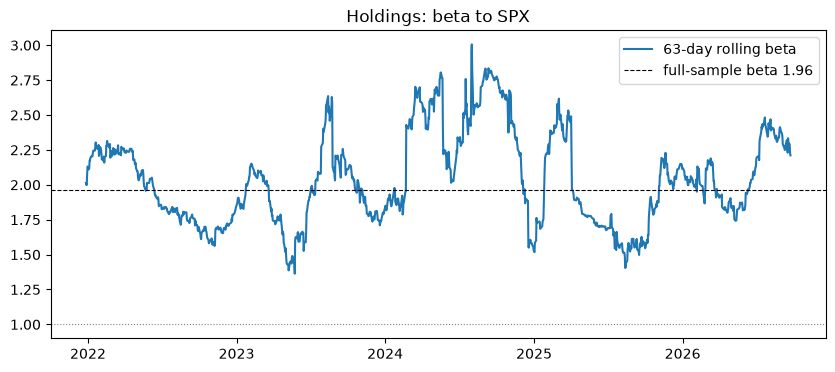

In [23]:
# Rolling beta against SPX over config.beta_window days
beta_data = pd.DataFrame({'Holdings': port_returns, 'SPX': spx_returns})
rolling_beta = (
    rolling_covariance(config, beta_data, ['Holdings', 'SPX'], config.beta_window)
    / beta_data['SPX'].rolling(config.beta_window).var()
)
full_beta = beta_data.cov().loc['Holdings', 'SPX'] / beta_data['SPX'].var()

fig, ax = plt.subplots(figsize=(10, 4))
plot_timeseries(rolling_beta, ax, {'label': f'{config.beta_window}-day rolling beta'})
ax.axhline(full_beta, color='black', linestyle='--', linewidth=0.8, label=f'full-sample beta {full_beta:.2f}')
ax.axhline(1, color='grey', linestyle=':', linewidth=0.8)
ax.set_title('Holdings: beta to SPX')
ax.legend()
plt.show()

The Holdings has a beta of 1.89 against the Fama-French Market factor, and a beta of 1.96 against SPX. This indicates the holdings portfolio is significantly overexposed to the market - which explains the performance observed in the returns and drawdowns charts. The holdings, equal-weight and market-cap-weight portfolios all perform better than the SPX during highs, fall lower during lows, and have far greater drawdowns, as shown by the earlier charts. This suggests their oversensitivity to changes in the broader market, compared to the SPX. The annualised alpha of the holdings portfolio is ~29.75%, with a t-value of 2.5 and a p-value of 0.01. This indicates the alpha observed may be significant, though it remains to be seen if this is merely a result of omitted risk factors in the model, hindsight in the weights, or luck.

### 3.6 Factor exposures (Fama-French five-factor)

In [24]:
factors = ['Mkt', 'SMB', 'HML', 'RMW', 'CMA']
ff5_data = pd.DataFrame({'Holdings': port_returns - ff['RF']}).join(ff[factors], how='inner')
ff5_summary, ff5_fitted = fama_french_five(config, ff5_data)
r_squared = 1 - ff5_fitted['resid'].var() / ff5_fitted['actual'].var()
print(f"Observations: {len(ff5_fitted)}, R-squared: {r_squared:.3f}")
ff5_summary

Observations: 1215, R-squared: 0.695


,coef,std err,t,P>|t|,0.025,0.975
Intercept,0.001372,0.000428,3.205705,1.382582e-03,0.000532,0.002211
Mkt,1.690299,0.051062,33.102755,1.372356e-171,1.590118,1.790479
SMB,-0.483026,0.071732,-6.733729,2.549883e-11,-0.623760,-0.342292
HML,-0.657754,0.118866,-5.533591,3.843590e-08,-0.890960,-0.424548
RMW,-0.172114,0.111240,-1.547237,1.220679e-01,-0.390359,0.046130
CMA,-0.092164,0.200033,-0.460747,6.450633e-01,-0.484615,0.300286


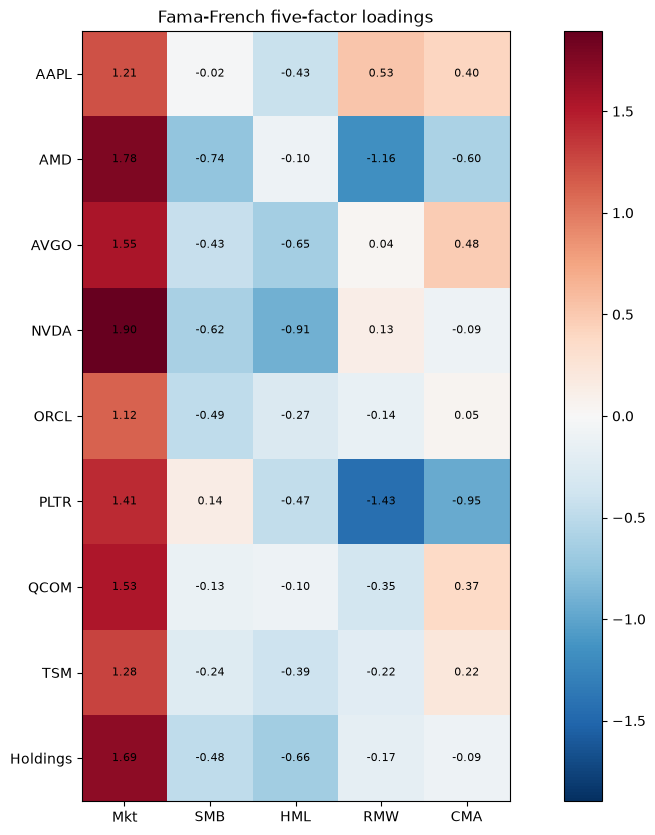

In [25]:
# Factor loadings for each constituent, to see which holdings drive the portfolio's exposures
loadings = {}
for ticker in ticker_universe:
    data = pd.DataFrame({ticker: return_panel[ticker] - ff['RF']}).join(ff[factors], how='inner')
    summary, _ = fama_french_five(config, data)
    loadings[ticker] = summary.loc[factors, 'coef']
loadings['Holdings'] = ff5_summary.loc[factors, 'coef']
loadings = pd.DataFrame(loadings).T

fig, ax = plt.subplots(figsize=(14, 10))
lim = loadings.abs().max().max()
im = heatmap(loadings, ax, {'cmap': 'RdBu_r', 'vmin': -lim, 'vmax': lim})
ax.set_xticks(range(len(factors)), factors)
ax.set_yticks(range(len(loadings)), loadings.index)
for i in range(loadings.shape[0]):
    for j in range(loadings.shape[1]):
        ax.text(j, i, f'{loadings.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Fama-French five-factor loadings')
plt.show()

The market beta drops from 1.89 to 1.69 after adding in the other Fama factors. The p-values of the RMW and CMA factors are larger than 0.1, indicating they are not significant. In contrast, the SMB and HML factors have p < 1e-7, and loadings of -0.48 and ~0.66. This indicates the SMB and HML factors are significant, and in particular negative, suggesting the Holdings portfolio behaves like large-capped growth stocks. With a t-value of 3.2, the alpha survives at about 0.14% per day, larger than with a pure CAPM regression. Meanwhile, the $R^2$ value of 0.695 indicates ~30% of the variance observed is unexplained by these factors. The market beta of every individual stock is larger than 1.0, and in particular NVDA and AMD seem to be the most sensitive to the market (betas of 1.90 and 1.78 respectively).

## 4. Strategy backtest

### 4.1 Hypothesis

**Strategy.** A simple moving average (SMA) crossover applied to each stock in the universe separately. A stock is held long when its short-window SMA is above its long-window SMA and short when it is below. `equal_active_weights` then splits the total exposure (1.0) equally across every stock with a non-zero signal, so gross exposure is always 1 and net exposure moves between -1 (all short) and +1 (all long).

**Primary parameter set**: short window 5 days, long window 21 days (the `DevConfig` defaults), fixed before any results were seen. The other parameter sets in 4.5 are there to measure how much selection could inflate the result, not to choose a winner.

**What it is expected to capture**: If stock-level trends persist for weeks to months, a crossover strategy should earn a positive net return of the costs, with smaller drawdown than the long-only strategy. However, frequent trend reversal could instead cause larger losses, and would be an idiosyncratic risk associated with this strategy.

### 4.2 Backtest design

- **Walk-forward scheme.** The first `train_frac = 0.5` of the 1,253 daily bars form the initial training window. The remaining bars are split into consecutive out-of-sample (OOS) test folds of `window_len = 21` bars, so the book is rebalanced roughly monthly. Training windows are *rolling*: each fold is trained on the fixed-length window of bars immediately before it.
- **Signals and weights.** For each fold, signals and weights are computed from the training slice only. The target weights are the weight row at the last training date.
- **Execution.** Trades execute at the close of the first OOS bar, one bar after the last date the signal could see. Holdings are carried in shares and drift with prices between rebalances. Each rebalance trades only the difference between the drifted book and the new target.
- **Costs.** `linear_cost` charges |shares| × price × 10 bps / 10,000 on every trade, deducted from cash on the rebalance bar. Section 4.4 varies the rate and also tries the square-root impact model `sqrt_cost`.
- **Look-ahead.** Signals use trailing rolling means only, so the value at date *t* uses prices up to *t*. The one-bar execution gap is applied by the backtester, and the fold boundaries mean no test-fold price enters the signal that trades it. `test_integration/` checks these properties end to end.
- **Benchmarks.** SPX over the same OOS dates, and a long-only equal-weight book run through the *same* backtester, fold schedule and cost model, so any difference comes from the signal.
- **Not modelled.** No financing or borrow cost: short proceeds sit in cash earning nothing and shorts are not charged for borrowing.

In [26]:
# Backtest settings, fixed before looking at results
BT_PARAMS = dict(window_params={'window_type': 'rolling', 'window_len': 21}, train_frac=0.5, cost_bps=10)
PRIMARY_SMA = [config.sma_short_window, config.sma_window]


def make_backtester(signal_fn, cost_model=linear_cost, **overrides):
    """A backtester over the case-study universe with the settings above, optionally overridden."""
    return WalkForwardBacktester(
        config=config,
        price_data=close_panel,
        volume_data=volume_panel,
        signal_fn=signal_fn,
        weight_fn=equal_active_weights,
        cost_model=cost_model,
        **{**BT_PARAMS, **overrides},
    )


def always_long(config, prices):
    """Benchmark signal: long every stock on every date."""
    return pd.DataFrame(1, index=prices.index, columns=prices.columns)

### 4.3 Results against the benchmark

In [27]:
strategy_bt = make_backtester(sma_crossover_portfolio)
strategy_bt.run(signal_args=PRIMARY_SMA, portfolio_args=[])
strategy_run = strategy_bt.runs[1]

long_only_bt = make_backtester(always_long)
long_only_bt.run(signal_args=[], portfolio_args=[])
long_only_run = long_only_bt.runs[1]

oos_index = strategy_run['net_returns'].index
print(f"Out-of-sample period: {oos_index[0].date()} to {oos_index[-1].date()} ({len(oos_index)} days, {len(strategy_run['fold_costs'])} rebalances)")

oos_returns = pd.DataFrame({
    'SMA crossover': strategy_run['net_returns'],
    'Long-only EW': long_only_run['net_returns'],
    'SPX': spx_returns.reindex(oos_index),
})
oos_perf = perf_summary(oos_returns)
for name, run in [('SMA crossover', strategy_run), ('Long-only EW', long_only_run)]:
    oos_perf.loc[name, 'Total turnover'] = run['results']['total_turnover']
    oos_perf.loc[name, 'Avg net exposure'] = run['results']['avg_net_exposure']
    oos_perf.loc[name, 'Total costs'] = run['fold_costs'].sum()

fmt(oos_perf, pct=['Cumulative return', 'Ann. return', 'Ann. volatility', 'Max drawdown'])

Out-of-sample period: 2024-03-25 to 2026-09-23 (627 days, 30 rebalances)


,Cumulative return,Ann. return,Ann. volatility,Sharpe,Sortino,Max drawdown,Calmar,Total turnover,Avg net exposure,Total costs
SMA crossover,14.3%,5.5%,24.7%,0.08,0.12,-23.7%,0.08,32.43,0.15,3510.04
Long-only EW,199.0%,55.3%,34.6%,1.49,2.55,-31.6%,1.64,3.39,1.0,556.84
SPX,47.2%,16.8%,15.6%,0.84,1.39,-18.9%,0.7,NaN,NaN,NaN


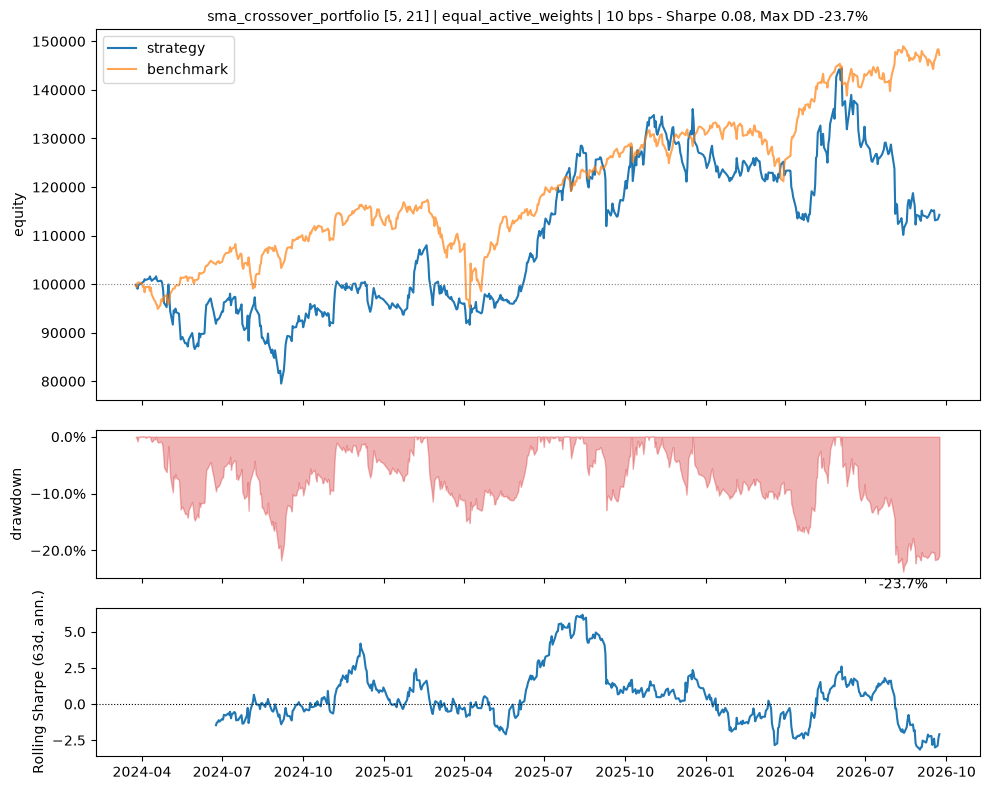

In [28]:
fig, axes = plot_backtest_summary(config, strategy_run, benchmark=spx_returns)
plt.show()

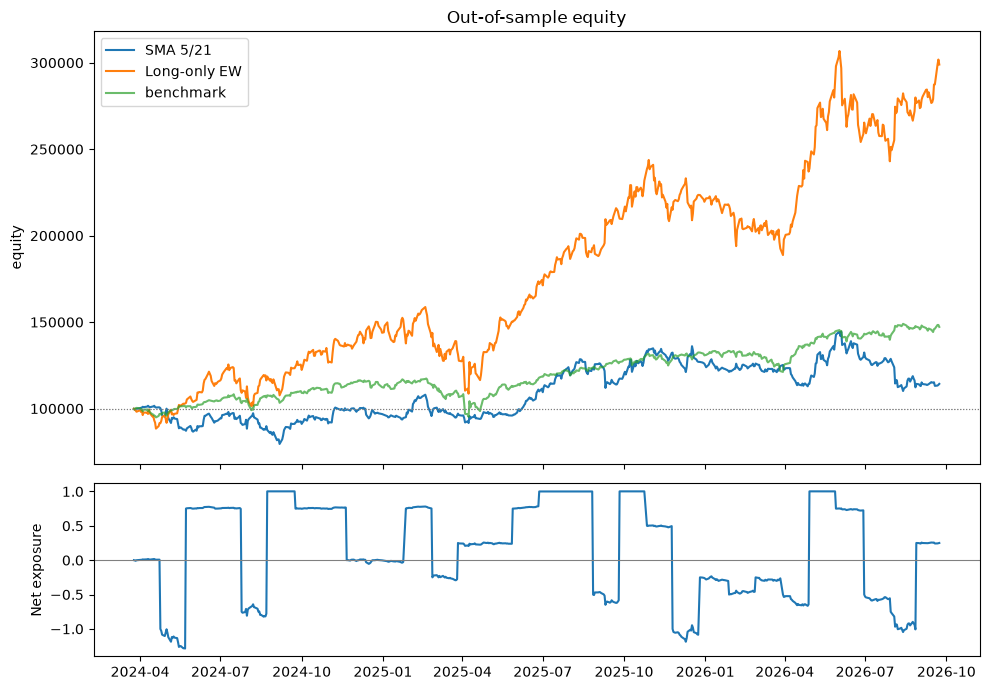

In [29]:
# Strategy against the long-only book, and the strategy's net exposure over time
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1.2]})
plot_equity_curve(config, strategy_run, axes[0], params_dict={'label': f'SMA {PRIMARY_SMA[0]}/{PRIMARY_SMA[1]}'})
plot_equity_curve(config, long_only_run, axes[0], params_dict={'label': 'Long-only EW'}, benchmark=spx_returns)
axes[0].legend(loc='upper left')
axes[0].set_title('Out-of-sample equity')

net_exposure = strategy_run['oos_weights'].sum(axis=1)
plot_timeseries(net_exposure, axes[1], {'label': 'net exposure'})
axes[1].axhline(0, color='grey', linewidth=0.8)
axes[1].set_ylabel('Net exposure')
fig.tight_layout()
plt.show()

The sharpe ratio of the strategy is 0.08 compared to the 1.49 observed in the long-only strategy. The net exposure is only 0.15 - this is closer to a market-neutral bet, which explains the somewhat lacklustre performance. Furthermore, a net exposure of 0.15 with a volatility of 24.7% is a lot of risk for little to no market exposure. The turnover of 32.4 in the strategy vs 3.4 in the long-only strategy netted $3510 vs only $557 in costs, which may have been a large contributer - this is further tested in Section 4.4. </br>
A market-neutral bet during the strong rallies observed from April 2025 to October 2025 and April 2026 to June 2026 would naturally perform poorer than a buy-and-hold strategy. Similarly, the max drawdown of the strategy was -23.7% vs the long-only's -31.6%, indicating the strategy was less sensitive to the broader market's performance. Nevertheless, the Calmar ratio of 0.08 vs 1.64 indicates that the long-only strategy did compensate for it's larger drawdowns. </br>
The strategy performed poorer than the SPX benchmark as well, indicating even just a buy-and-hold strategy in the index would have been better. The strategy seems to primarily lose when it opts to short it's positions (as seen in the net exposure chart), indicating that the trend for shorting is a poor indicator, or the trend simply reverses too quickly. In particular, the signal is taken at the last training date and held throughout the 21 day folds, so they are only traded monthly. This may have been a key factor in the poor performance of the strategy. Different short/long windows are tested in Section 4.5 to further verify this.

### 4.4 Sensitivity to transaction costs

sqrt_cost at 10 bps: Sharpe 0.13, ann. return 6.8%


,Strategy Sharpe,Strategy ann. return,Long-only Sharpe,Long-only ann. return
cost (bps),,,,
0,0.13,6.9%,1.5,55.5%
5,0.1,6.2%,1.5,55.4%
10,0.08,5.5%,1.49,55.3%
20,0.02,4.2%,1.49,55.1%
50,-0.14,0.2%,1.47,54.4%


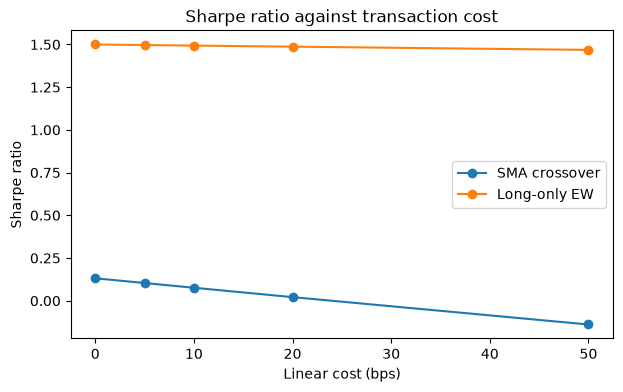

In [30]:
# Re-run the primary strategy and the long-only book at several linear cost levels
cost_levels = [0, 5, 10, 20, 50]
cost_rows = {}
for bps in cost_levels:
    strat = make_backtester(sma_crossover_portfolio, cost_bps=bps).run(PRIMARY_SMA, [])
    bench = make_backtester(always_long, cost_bps=bps).run([], [])
    cost_rows[bps] = {
        'Strategy Sharpe': strat['sharpe'], 'Strategy ann. return': strat['ann_return'],
        'Long-only Sharpe': bench['sharpe'], 'Long-only ann. return': bench['ann_return'],
    }
cost_table = pd.DataFrame(cost_rows).T
cost_table.index.name = 'cost (bps)'

# Square-root impact: cost_bps scales with sqrt(order size / daily volume), so small orders pay far less than 10 bps
sqrt_result = make_backtester(sma_crossover_portfolio, cost_model=sqrt_cost).run(PRIMARY_SMA, [])
print(f"sqrt_cost at 10 bps: Sharpe {sqrt_result['sharpe']:.2f}, ann. return {sqrt_result['ann_return']:.1%}")

display(fmt(cost_table, pct=['Strategy ann. return', 'Long-only ann. return']))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(cost_table.index, cost_table['Strategy Sharpe'], marker='o', label='SMA crossover')
ax.plot(cost_table.index, cost_table['Long-only Sharpe'], marker='o', label='Long-only EW')
ax.set_xlabel('Linear cost (bps)')
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe ratio against transaction cost')
ax.legend()
plt.show()

The annual returns for the SMA crossover strategy is far more sensitive to transaction costs than the long-only strategy, as one would expect for an active trading strategy. The drop is particularly large, reducing from 6.9% annualised returns to 0.2% as the cost moved from 0 to 50, and the strategy breaks even at around 24 bps. Even at 0 bps, the Sharpe is only 0.14, and increasing costs makes it worse. The sqrt cost returns a sharpe of 0.13, which is somewhat expected as orders in a $100k book are negligible compared to the average daily volume. In contrast to the SMA strategy, the long-only returns only reduced from 55.5% to 54.4%, and its Sharpe ratio also remained relatively constant throughout the cost changes (1.5 at 0bps to 1.47 at 50bps). 

### 4.5 Is the result distinguishable from luck?

Parameter sets tried: 14


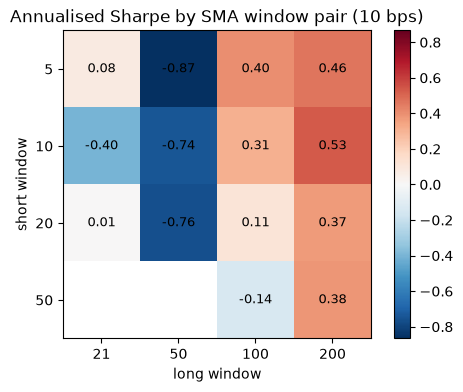

In [31]:
# Every short/long window pair from the grid, all at the same 10 bps cost
short_windows = [5, 10, 20, 50]
long_windows = [21, 50, 100, 200]
grid = [(s, l) for s in short_windows for l in long_windows if s < l]

grid_bt = make_backtester(sma_crossover_portfolio)
for s, l in grid:
    grid_bt.run(signal_args=[s, l], portfolio_args=[])

trials = pd.DataFrame({
    f"{run['signal_args'][0]}/{run['signal_args'][1]}": run['net_returns'] for run in grid_bt.runs.values()
})
trial_sharpes = pd.Series({name: ann_sharpe(config, trials[name]) for name in trials})
print(f"Parameter sets tried: {len(grid)}")

sharpe_grid = pd.DataFrame(
    [(s, l, trial_sharpes[f'{s}/{l}']) for s, l in grid], columns=['short', 'long', 'sharpe']
).pivot(index='short', columns='long', values='sharpe')
fig, ax = plt.subplots(figsize=(6, 4))
lim = np.nanmax(np.abs(sharpe_grid.values))
im = heatmap(sharpe_grid, ax, {'cmap': 'RdBu_r', 'vmin': -lim, 'vmax': lim})
ax.set_xticks(range(len(sharpe_grid.columns)), sharpe_grid.columns)
ax.set_yticks(range(len(sharpe_grid.index)), sharpe_grid.index)
ax.set_xlabel('long window')
ax.set_ylabel('short window')
for i in range(sharpe_grid.shape[0]):
    for j in range(sharpe_grid.shape[1]):
        if not np.isnan(sharpe_grid.iloc[i, j]):
            ax.text(j, i, f'{sharpe_grid.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax)
ax.set_title('Annualised Sharpe by SMA window pair (10 bps)')
plt.show()

In [32]:
# Probabilistic Sharpe (no deflation) and deflated Sharpe for the primary set and the best set
primary = f'{PRIMARY_SMA[0]}/{PRIMARY_SMA[1]}'
best = trial_sharpes.idxmax()
off_diagonal = trials.corr().values[~np.eye(len(trials.columns), dtype=bool)]
print(f"Best set: {best} (Sharpe {trial_sharpes[best]:.2f}); primary set: {primary} (Sharpe {trial_sharpes[primary]:.2f})")
print(f"Mean pairwise correlation between trials: {off_diagonal.mean():.2f}")

pd.DataFrame({
    'PSR (vs Sharpe 0)': {name: probabilistic_sharpe(config, trials[name]) for name in [primary, best]},
    f'DSR ({len(grid)} trials)': {name: deflated_sharpe(config, trials, selected=name) for name in [primary, best]},
}).round(3)

Best set: 10/200 (Sharpe 0.53); primary set: 5/21 (Sharpe 0.08)
Mean pairwise correlation between trials: 0.56


,PSR (vs Sharpe 0),DSR (14 trials)
5/21,0.621,0.146
10/200,0.831,0.345


In [33]:
# The trials are correlated, so the effective number of independent trials is below the raw count.
# Deflated Sharpe of the best set across a range of assumed trial counts:
pd.Series(
    {n: deflated_sharpe(config, trials, n_trials=n) for n in [2, 3, 5, 8, len(grid)]},
    name=f'DSR of {best}',
).rename_axis('n_trials').to_frame().round(3)

,DSR of 10/200
n_trials,
2,0.710
3,0.616
5,0.511
8,0.429
14,0.345


From the heatmap it can be seen that there was a better performing short vs long window pair of 10/200. In general, the long window being 200 performed better than all strategies with a smaller long window value. The PSR value of the 10/200 pair was 0.831, while the DSR value of 0.710 at 2 trials. Even without deflating the PSR, it is far from the desired threshold of 0.95, indicating the performance of the 10/200 window is likely luck-based.

## 5. Limitations

- **No financing or margin model.** Short positions earn nothing on their proceeds and pay no borrow fee, and leverage is not charged for.
- **Survivorship and hindsight in the universe.** The eight stocks are current holdings, chosen with knowledge of how they performed. The risk profile in section 3 also applies today's weights to the whole history.
- **Constant-weight portfolio.** Section 3 assumes daily rebalancing to fixed weights, which is not how the holdings were actually traded.
- **Short sample.** Five years of daily data, of which about two and a half are out of sample for the backtest.
- **One strategy family.** Only SMA crossovers with equal active weights were tested.
- **Execution and costs.** Trades fill at the close with a linear cost and no slippage beyond it. The square-root model is only a rough check.
- **Factor data coverage.** The Fama-French file ends before the price data, so the factor regressions use a slightly shorter window.
- **Signals sampling time.** Signals are only sampled at the monthly rebalance, which may be ill-suited for a trend following strategy with frequent trend reversions.
- **Constant risk-free rate.** The risk-free rate (rfr) used for this test was held constant at 3.63% annual, a time-varying rfr would provide more accurate results.

## 6. Conclusions

The cumulative returns of the Holdings portfolio was ~765%, far greater than the benchmark SPX's 73.4%. The equally-weighted and market-cap-weighted portfolios also performed well, at around 446% and 513% cumulative returns respectively. However, the factor regression showed that the portfolios have very high market beta (>1.8), and the max drawdowns were particularly greater than that of SPX (-45% to -58% compared to -25%). Nevertheless, the Calmar ratio of the three portfolios were greater than SPX's (~0.8 vs ~0.3), indicating that the drawdowns are somewhat compensated. The CAPM regression revealed an alpha of ~29.8% annually with p=0.01, and adding in the Fama-French factors brought this up to ~34.3% annually at p=0.0013. This indicates that additional factors may be missing from the model, with ~0.14% daily alpha unexplained currently. The R^2 value of 0.695 suggests about 30% of the variance may be stock specific as well. </br>
The backtest using a trend-following SMA crossover strategy showed that the strategy performed far worse than a simple long-only strategy, with a sharpe ratio of 0.08 vs 1.49 under identical costs. Varying the transaction costs further revealed the strategy was very sensitive to cost, breaking even around 20-50bps and dropping from 0.13 Sharpe at 0 bps to -0.14 Sharpe at 50bps. The best window choice could not be distinguished from luck (as observed from the DSR of 0.71 and PSR of 0.831), while the primary window selected wasn't profitable after increasing costs beyond 24 bps.</br>

**Next steps**: 
- The RSI mean-reversion strategy can be backtested instead, observing whether short-horizon reversal does better than trend-following here.
- The 0.14% daily alpha unexplained by the Fama 5 factor regression model suggests regression against other factors could be useful as well, in particular, the momentum factor (UMB) should be added.
- A long/flat variant of the crossover may perform better, since losses mainly occur when shorts are taken.
- A window_len value matching the signal horizon may perform better given the backtesting implementation.
- Testing portfolios with tickers not currently held would likely produce a more interesting result. In particular, diversifying away from the semiconductor and technology sectors may reduce risk and drawdowns.
- The current library struggles to obtain data from IBKR that is not currently held, so additional support for yfinance and other data retrieval methods will be added.
- No portfolio optimisation methods have been implemented yet, so the above portfolios may be further optimisable to either reduce risk or improve performance.

## References

1. Bailey, D. H. and López de Prado, M. (2012). The Sharpe ratio efficient frontier. *Journal of Risk*, 15(2), 3–44.
2. Bailey, D. H. and López de Prado, M. (2014). The deflated Sharpe ratio: correcting for selection bias, backtest overfitting and non-normality. *Journal of Portfolio Management*, 40(5), 94–107.
3. Fama, E. F. and French, K. R. (2015). A five-factor asset pricing model. *Journal of Financial Economics*, 116(1), 1–22.
4. French, K. R. Data Library. https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/data_library.html
5. Moskowitz, T. J., Ooi, Y. H. and Pedersen, L. H. (2012). Time series momentum. *Journal of Financial Economics*, 104(2), 228–250.
6. Newey, W. K. and West, K. D. (1987). A simple, positive semi-definite, heteroskedasticity and autocorrelation consistent covariance matrix. *Econometrica*, 55(3), 703–708.
7. Bollerslev, T. (1986). Generalized autoregressive conditional heteroskedasticity. *Journal of Econometrics*, 31(3), 307–327.